# Comparativo: NLLB × M2M100


In [ ]:
!pip install transformers
!pip install sentencepiece
!pip install sacrebleu

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 8.5 MB/s eta 0:00:00


In [ ]:
import re
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
import sacrebleu

# Nota: este notebook apenas monta o pipeline. O download dos pesos acontece quando você executar as células.

## Texto original (italiano) e referência (português)

Coloque o texto italiano que deseja traduzir em `TEXTO_ITALIANO` e a tradução de referência em `REFERENCIA_PORTUGUES`.

In [ ]:
## --- Substitua abaixo ---
TEXTO_ITALIANO = """
Proémio, n. 1
"Il sacro Concilio, udendo con religiosa attenzione la parola di Dio e proclamandola con ferma fiducia, fa sue queste parole di san Giovanni: «Vi annunziamo la vita eterna, que era presso il Padre e si manifestò a noi: vi annunziamo ciò che abbiamo veduto e udito, affinché anche voi siate in comunione con noi, e la nostra comunione sia col Padre e col Figlio suo Gesù Cristo» (1 Gv 1,2-3)."

"Perciò, seguindo i Concili Tridentino e Vaticano I, esso intende proporre l'autentica dottrina sulla divina Rivelazione e sulla sua trasmissione, affinché, per l'annunzio della salvezza, il mondo intero ascoltando creda, credendo speri, sperando ami."

Capítulo I, n. 2
"Piacque a Dio nella sua bontà e sapienza rivelare se stesso e far conoscere il mistero della sua volontà (cfr. Ef 1,9), mediante il quale gli uomini per mezzo di Cristo, Verbo fatto carne, nello Spirito Santo hanno accesso al Padre e sono resi partecipi della divina natura (cfr. Ef 2,18; 2 Pt 1,4)."

"Con questa rivelazione infatti, Dio invisibile (cfr. Col 1,15; 1 Tm 1,17) nel suo immenso amore parla agli uomini come ad amici (cfr. Es 33,11; Gv 15,14-15) e si intrattiene con essi (cfr. Bar 3,38), per invitarli e ammetterli alla comunione con sé."

"Questa «economia» della Rivelazione avviene con eventi e parole intimamente connessi tra loro, in modo che le opere, compiute da Dio nella storia della salvezza, manifestano e rafforzano la dottrina e le realtà significate dalle parole, e le parole a loro volta proclamano le opere e chiariscono il mistero in esse contenuto."

"Però la profonda verità, sia riguardo a Dio, sia riguardo alla salvezza degli uomini, per mezzo di questa Rivelazione, risplende a noi in Cristo, che è insieme il mediatore e la pienezza di tutta intera la Rivelazione (2)."

Capítulo I, n. 3
"Dio, il quale crea e conserva tutte le cose per il Verbo (cfr. Gv 1,3), offre agli uomini nelle cose create una perenne testimonianza di sé (cfr. Rm 1,19-20). Inoltre, volendo aprire la via della salvezza soprannaturale, fin dal principio manifestò se stesso ai Progenitori."

"Dopo la loro caduta, con la promessa della redenzione, li sollevò alla speranza della salvezza (cfr. Gn 3,15), e senza interruzione ebbe cura del genere umano, per dare la vita eterna a tutti coloro que cercano la salvezza con la perseveranza nelle buone opere (cfr. Rm 2,6-7)."

"A suo tempo chiamò Abramo, per fare di lui un popolo grande (cfr. Gn 12,2), popolo che dopo i Patriarchi istruì per mezzo di Mosè e dei profeti, affinché lo riconoscesse come l'unico Dio vivo e vero, padre provvido e giusto giudice, e attendesse il Salvatore promesso; e così preparò attraverso i secoli la via al Vangelo."

Capítulo I, n. 4
"Dopo aver a più riprese e in più modi parlato per mezzo dei profeti, « Dio ultimamente, in questi giorni, ha parlato a noi per mezzo del Figlio » (Eb 1,1-2)."

"Ha mandato infatti il Figlio suo, cioè il Verbo eterno, che illumina tutti gli uomini, affinché dimorasse tra gli uomini e ad essi spiegasse l'intimo di Dio (cfr. Gv 1,1-18)."

"Gesù Cristo, Verbo fatto carne, mandato come «uomo agli uomini» (3), «parla le parole di Dio» (Gv 3,34) e porta a compimento l'opera di salvezza que il Padre gli aveva affidato (cfr. Gv 5,36; 17,4)."

"Perciò chi vede lui, vede anche il Padre (cfr. Gv 14,9). Egli, con tutta la sua presenza e manifestazione, con le parole e con le opere, con i segni e con i miracoli, e specialmente con la sua morte e gloriosa risurrezione, e infine con l'invio dello Spirito di verità, compie e completa la Rivelazione e la conferma con la testimonianza divina, ossia che Dio è con noi per liberarci dalle tenebre del peccato e della morte e per risuscitarci a vita eterna."

"Per questo l'Economia cristiana, in quanto Alleanza nuova e definitiva, non passerà mai, e non si dovrà attendere nessun'altra rivelazione pubblica prima della manifestazione gloriosa del Signore nostro Gesù Cristo (cfr. 1 Tm 6,14; Tt 2,13)."

Capítulo I, n. 5
"A Dio che rivela è dovuta «l'obbedienza della fede» (Rm 16,26; cfr. Rm 1,5; 2 Cor 10,5-6)."

"Con la fede infatti l'uomo si abbandona interamente a Dio liberamente, prestando «con l'intelletto e con la volontà l'ossequio pieno a Dio che rivela» (4) e dando il suo assenso volontario alla rivelazione fatta da lui."

"Per prestare questa fede, é necessaria la grazia di Dio che previene e soccorre, e gli aiuti interiori dello Spirito Santo, il quale muova il cuore e lo rivolga a Dio, apra gli occhi della mente e dia «a tutti soavità nel consentire e nel credere alla verità» (5)."

"Affinché l'intelligenza della Rivelazione diventi sempre più profonda, lo stesso Spirito Santo perfeziona continuamente la fede per mezzo dei suoi doni."

Capítulo I, n. 6
"Con la divina Rivelazione Iddio volle manifestare e comunicare se stesso e i decreti della sua volontà per la salvezza degli uomini, «per renderli cioè partecipi dei beni divini, che trascendono assolutamente l'intelligenza della mente umana» (6)."

"Il santo Concilio professa que «Dio, principio e fine di tutte le cose, può essere conosciuto con certezza con la luce naturale della ragione umana a partire dalle cose create» (cfr. Rm 1,20);"

"ma insegna pure che è merito della Rivelazione divina se «tutto ciò que nelle cose divine non è per sé inaccessibile alla ragione umana, può, anche nell'attuale condizione del genere umano, essere conosciuto da tutti facilmente, con ferma certezza e senza mescolanza di errore» (7)."

Capítulo II, n. 7
"Dio con somma benignità dispose che quanto Egli aveva rivelato per la salvezza di tutte le genti, rimanesse per sempre integro e venisse trasmesso a tutte le generazioni."

"Perciò Cristo Signore, nel quale si compie tutta intera la Rivelazione del sommo Dio (cfr. 2 Cor 1,20; 3,16-4,6), dopo aver portato a compimento in sé tutta la verità de Dio predicò di persona (1), comandò agli apostoli che predicassero a tutti, come la fonte di ogni verità salutare e di ogni regola morale, quel Vangelo che egli prima aveva promesso per mezzo dei profeti e che poi aveva adempiuto e promulgato di persona, comunicando così ad essi i doni divini."

"Questo venne fedelmente eseguito, sia dagli apostoli, i quali nella predicazione orale, con gli esempi e le istituzioni trasmisero sia ciò che avevano ricevuto dalla bocca del Cristo vivendo con lui e osservandolo agire, sia ciò che avevano imparato dai suggerimenti dello Spirito Santo, sia da quegli apostoli o da uomini della loro cerchia, i quali, per ispirazione dello stesso Spirito Santo, misero per iscritto il messaggio della salvezza (2)."

"Gli apostoli poi, affinché il Vangelo si conservasse sempre integro e vivo nella Chiesa, lasciarono come loro successori i vescovi, ad essi «affidando il loro proprio posto di maestri» (3)."

"Questa sacra Tradizione e la sacra Scrittura di entrambi i Testamenti sono dunque come uno specchio nel quale la Chiesa pellegrina in terra contempla Dio, dal quale tutto riceve, finché giunga a vederlo faccia a faccia, com'egli è (cfr. 1 Gv 3,2)."

Capítulo II, n. 8
"Così la predicazione apostolica, che è espressa in modo speciale nei libri ispirati, doveva con una successione ininterrotta conservarsi sino alla fine dei tempi."

"Perciò gli apostoli, trasmettendo ciò che essi stessi avevano ricevuto, ammoniscono i fedeli ad attenersi alle tradizioni che avevano appreso o con la parola, o per scritto (cfr. 2 Ts 2,15), e a combattere per la fede che ad essi era stata trasmessa una volta per tutte (cfr. Gd 3)(4)."

"Ora, ciò que fu trasmesso dagli apostoli, comprende tutto quanto contribuisce alla santità di vita e al incremento della fede nel popolo di Dio; e così la Chiesa, nella sua dottrina, nella sua vita e nel suo culto, perpetua e trasmette a tutte le generazioni tutto ciò che essa è, tutto ciò che essa crede."

"Questa Tradizione, che trae origine dagli apostoli, progredisce nella Chiesa con l'assistenza dello Spirito Santo (5)."

"Cresce infatti la comprensione, tanto delle cose quanto delle parole trasmesse, sia con la contemplazione e lo studio dei credenti, che le meditano in cuor loro (cfr. Lc 2,19 e 51), sia con l'intelligenza interiore, che essi provano delle cose spirituali, sia per la predicazione di coloro i quali con la successione episcopale hanno ricevuto un carisma sicuro di verità."

"La Chiesa cioè, nel corso dei secoli, tende incessantemente alla pienezza della verità divina, finché in essa giungano a compimento le parole di Dio."

"Le asserzioni dei santi Padri attestano la presenza vivificatrice di questa Tradizione, i cui tesori si riversano nella pratica e nella vita della Chiesa credente e orante."

"Per mezzo di questa medesima Tradizione la Chiesa conosce il canone completo dei libri sacri, e le stesse sacre Scritture in essa vengono comprese più profondamente e rese incessantemente operanti;"

"e così Dio, il quale parlò nel passato, non cessa di conversare con la Sposa del suo Figlio diletto;"

"e lo Spirito Santo, per mezzo del quale la voce viva del Vangelo risuona nella Chiesa, e per mezzo di questa nel mondo, introduce i credenti in tutta intera la verità e fa sì che in essi risieda abbondantemente la parola di Cristo (cfr. Col 3,16)."

Capítulo II, n. 9
"La sacra Tradizione e la sacra Scrittura sono dunque strettamente connesse e comunicanti tra loro."

"Infatti, ambedue scaturiscono dalla medesima sorgente divina, formano in certo qual modo una cosa sola e tendono allo stesso fine."

"La sacra Scrittura infatti è la parola di Dio in quanto è messa per iscritto sotto l'ispirazione dello Spirito divino."

"Quanto alla sacra Tradizione, essa trasmette integralmente la parola di Dio, affidata da Cristo Signore e dallo Spirito Santo agli Apostoli, ai loro successori, affinché questi, illuminati dallo Spirito di verità, nella loro predicazione la conservino fedelmente, la espongano e la diffondano."

"Ne consegue che la Chiesa non attinge la certezza su tutte le cose rivelate dalla sola sacra Scrittura."

"Perciò l'una e l'altra devono essere accettate e venerate con pari sentimento di pietà e di riverenza (6)."

Capítulo II, n. 10
"La sacra Tradizione e la sacra Scrittura costituiscono un solo sacro deposito della parola di Dio affidato alla Chiesa;"

"nell'aderire ad esso, tutto il popolo santo, unito ai suoi Pastori, persevera costante nell'insegnamento degli Apostoli e nella comunione, nella frazione del pane e nella preghiera (cfr. At 2,42 gr.), in modo che nel ritenere, praticare e professare la fede trasmessa, si crei una singolare concordia di vescovi e di fedeli (7)."

"L'ufficio poi d'interpretare autenticamente la parola di Dio scritta o trasmessa, è affidato al solo Magistero vivo della Chiesa (8), la cui autorità è esercitata nel nome di Gesù Cristo (9)."

"Il Magistero, tuttavia, non è superior alla parola di Dio, ma la serve, insegnando soltanto ciò que é stato trasmesso, in quanto, per divino mandato e con l'assistenza dello Spirito Santo, piamente la ascolta, santamente la custodisce e fedelmente la espone, attingendo da questo unico deposito della fede tutto ciò che propone da credere come divinamente rivelato."

"È chiaro dunque che la sacra Tradizione, la sacra Scrittura e il Magistero della Chiesa, per sapientissima disposizione di Dio, sono tra loro così connessi e congiunti che nessuno d'essi sussiste senza gli altri, e tutti insieme, ciascuno a suo modo, sotto l'azione dello Spirito Santo, contribuiscono efficacemente alla salvezza delle anime."

Capítulo III, n. 11
"Le verità divinamente rivelate, che nei libri della sacra Scrittura sono contenute ed espresse, furono scritte per ispirazione dello Spirito Santo."

"La santa Madre Chiesa, secondo la fede degli Apostoli, ritiene sacri e canonici tutti i libri sia dell'Antico che del Nuovo Testamento con tutte le loro parti, perché scritti per ispirazione dello Spirito Santo (cfr. Gv 20,31; 2 Tm 3,16; 2 Pt 1,19-21; 3,15-16), hanno Dio per autore e como tali sono stati affidati alla Chiesa stessa (1)."

"Per la composizione dei libri sacri, Dio scelse degli uomini di cui si servì nel possesso delle loro facoltà e capacità, affinché, agendo egli in essi e per essi (2), scrivessero come veri autori, tutte e soltanto quelle cose che Egli voleva (3)."

"Poiché dunque tutto quello che gli autori ispirati o agiografi asseriscono è da ritenersi asserito dallo Spirito Santo, ne consegue que i libri della Scrittura insegnano con certezza, fedelmente e senza errore la verità que Dio per la nostra salvezza volle fosse consegnata nelle sacre Lettere (4)."

"Perciò «tutta la Scrittura è ispirata da Dio e utile per insegnare, per convincere, per correggere, per educare alla giustizia, affinché l'uomo di Dio sia perfetto, pronto per ogni opera buona» (2 Tm 3,16-17 gr.)."

Capítulo III, n. 12
"Dio nella sacra Scrittura ha parlato per mezzo di uomini e alla maniera umana (5). Per l'interprete della sacra Scrittura, dunque, per conoscere ciò que Dio ha voluto comunicarci, bisogna ricercare con attenzione che cosa gli agiografi abbiano veramente voluto significare e a Dio sia piaciuto manifestare con le loro parole."

"Per scoprire l'intenzione degli agiografi, si deve tener conto tra l'altro anche dei «generi letterari»."

"La verità infatti viene diversamente proposta ed espressa in testi in vario modo storici, o profetici, o poetici, o in altri modi di dire."

"È necessario che l'interprete ricerchi il senso che l'agiografo in determinate circostanze, secondo le condizioni del suo tempo e della sua cultura, e servendosi dei generi letterari allora in uso, intendeva esprimere e di fatto espresse (6)."

"Per comprendere infatti esattamente ciò che l'autore sacro volle asserire, si deve tener conto convenientemente sia dei modi nativi di sentire, di esprimersi e di raccontare vigenti al tempo dell'agiografo, sia di quelli che in quel tempo erano abitualmente in uso nei rapporti umani (7)."

"Ma poiché la sacra Scrittura deve essere letta e interpretata con lo stesso Spirito col quale fu scritta (8), per ricavarne con esattezza il senso dei testi sacri, si deve badare con non minore diligenza al contenuto e alla unità di tutta la Scrittura, tenuto debito conto della viva Tradizione di tutta la Chiesa e dell'analogia della fede."

"È compito degli esegeti lavorare secondo queste regole, per una più profonda intelligenza ed esposizione del senso della sacra Scrittura, affinché per mezzo di studi in qualche modo preparatori, maturi il giudizio della Chiesa."

"Tutto ciò infatti che concerne il modo di interpretare la Scrittura, è sottoposto in ultima istanza al giudizio della Chiesa, la quale adempie il divino mandato e ministero di custodire e interpretare la parola di Dio (9)."

Capítulo III, n. 13
"Pertanto nella sacra Scrittura, ferma restando la verità e la santità di Dio, si manifesta la mirabile «condiscendenza» della Sapienza eterna, «perché impariamo quale ineffabile benignità di Dio e"

"quanta sollecitudine Egli abbia avuto per la nostra natura» (10)."

"Le parole di Dio infatti, espresse con lingue umane, si sono fatte simili al parlare umano, così come già il Verbo dell'eterno Padre, avendo assunto la carne dell'umana debolezza, divenne simile agli uomini."

Capítulo IV, n. 14
"Dio con sommo amore, volendo e preparando la salvezza di tutto il genere umano, con singolare disegno si scelse un popolo, al quale affidare le sue promesse."

"Dopo aver stabilito un'alleanza con Abramo (cfr. Gn 15,18), e per mezzo di Mosè con il popolo d'Israele (cfr. Es 24,8), a questo popolo eletto si rivelò come l'unico Dio vivo e vero, in modo que Israele potesse conoscere per esperienza il piano di Dio nei riguardi degli uomini, e lo comprendesse con chiarezza e sempre più a fondo attraverso la parola dello stesso Dio che parlava per bocca dei profeti, e lo diffondesse in modo più ampio tra le genti (cfr. Sal 21,28-29; 95,1-3; Is 2,1-4; Ger 3,17)."

"L'economia della salvezza, annunziata in precedenza, narrata e spiegata dagli autori sacri, si incontra nei libri dell'Antico Testamento come vera parola di Dio."

"Per questo tali libri divinamente ispirati conservano un valore perenne: «Tutto ciò infatti che fu scritto, fu scritto per nostra istruzione, affinché mediante la pazienza e la consolazione delle Scritture, avessimo la speranza» (Rm 15,4)."

Capítulo IV, n. 15
"L'economia dell'Antico Testamento era soprattutto ordinata a preparare, ad annunziare profeticamente (cfr. Lc 24,44; Gv 5,39; 1 Pt 1,10) e a significare con varie figure (cfr. 1 Cor 10,11) l'avvento di Cristo, redentore universale, e del regno messianico."

"I libri dell'Antico Testamento, secondo la condizione del genere umano prima del tempo della salvezza attuata da Cristo, manifestano a tutti la conoscenza di Dio e dell'uomo e i modi con cui Dio giusto e misericordioso tratta gli uomini."

"Questi libri, sebbene contengano anche cose imperfette e caduche, dimostrano tuttavia una vera pedagogia divina (1)."

"Perciò i fedeli devono accogliere con devozione questi libri, i quali esprimono il vivo senso di Dio, e nei quali si trovano sublimi dottrine su Dio, salutari insegnamenti sulla vita dell'uomo e mirabili tesori di orazioni, e finalmente nei quali è nascosto il mistero della nostra salvezza."

Capítulo IV, n. 16
"Perciò Dio, l'ispiratore e l'autore dei libri dell'uno e dell'altro Testamento, ha sapientemente disposto che il Nuovo fosse nascosto nell'Antico e l'Antico fosse svelato nel Nuovo (2)."

"Quantunque infatti Cristo abbia fondato la Nuova Alleanza nel suo sangue (cfr. Lc 22,20; 1 Cor 11,25), tuttavia i libri dell'Antico Testamento, integralmente assunti nella predicazione evangelica (3), acquistano e manifestano il loro pieno significato nel Nuovo Testamento (cfr. Mt 5,17; Lc 24,27; Rm 16,25-26; 2 Cor 3,14-16), che essi a loro volta illuminano e spiegano."

Capítulo V, n. 17
"La parola di Dio, che è potenza di Dio per la salvezza di chiunque crede (cfr. Rm 1,16), si presenta ed manifesta la sua forza in modo eminente negli scritti del Nuovo Testamento."

"Quando infatti venne la pienezza dei tempi (cfr. Gal 4,4), il Verbo si fece carne e abitò tra noi pieno di grazia e di verità (cfr. Gv 1,14)."

"Cristo stabilì il regno di Dio sulla terra, manifestò con opere e parole il Padre suo e se stesso, e portò a compimento l'opera sua con la morte, la risurrezione e la gloriosa ascensione, e con l'invio dello Spirito Santo."

"Elevato da terra, egli attira tutti a sé (cfr. Gv 12,32 gr.), lui che solo ha parole di vita eterna (cfr. Gv 6,68)."

"Questo mistero però non fu palesato alle altre generazioni, come ora è stato rivelato ai suoi santi apostoli e ai profeti nello Spirito Santo (cfr. Ef 3,4-6 gr.), affinché predicassero l'Evangelo, suscitassero la fede in Gesù Cristo Signore e raccogliessero la Chiesa."

"Di tutte queste cose gli scritti del Nuovo Testamento presentano una testimonianza perenne e divina."

Capítulo V, n. 18
"A nessuno sfugge che tra tutte le Scritture, anche del Nuovo Testamento, i Vangeli possiedono una meritata superiorità, in quanto costituiscono la principale testimonianza relativa alla vita e alla dottrina del Verbo incarnato, nostro Salvatore."

"La Chiesa ha ritenuto e ritiene sempre e in ogni luogo che i quattro Vangeli sono di origine apostolica."

"Infatti, ciò che gli apostoli per mandato di Cristo predicarono, in seguito, per ispirazione dello Spirito Santo, fu dagli stessi e da uomini della loro cerchia tramandato in scritti, che sono il fondamento della fede, cioè l'Evangelo quadriforme secondo Matteo, Marco, Luca e Giovanni (1)."

Capítulo V, n. 19
"La santa Madre Chiesa ha ritenuto e ritiene con fermezza e con la massima costanza che i quattro Vangeli, di cui afferma senza esitazione la storicità, trasmettono fedelmente le cose che Gesù Figlio di Dio, durante la sua vita tra gli uomini, effettivamente operò e insegnò per la loro salvezza eterna, fino al giorno in cui fu assunto in cielo (cfr. At 1,1-2)."

"Gli apostoli poi, dopo l'Ascensione del Signore, trasmisero ai loro uditori ciò che egli aveva detto e fatto, con quella più completa intelligenza delle cose, di cui essi, istruiti dagli eventi gloriosi di Cristo e illuminati dallo Spirito di verità (2), godevano (3)."

"Gli autori sacri, poi, scrissero i quattro Vangeli, scegliendo alcune cose tra le molte tramandate a voce o già per iscritto, facendone una sintesi, o spiegandole avuto riguardo alla situazione delle Chiese, conservando infine il carattere di predicazione, sempre però in modo da riferire su Gesù cose vere e sincere (4)."

"Essi infatti, attingendo sia dai propri ricordi sia dalla testimonianza di quelli «che fin dal principio furono testimoni oculari e ministri della parola», scrissero con l'intenzione di farci conoscere la «verità» (cfr. Lc 1,2-4) degli insegnamenti che abbiamo ricevuto."

Capítulo V, n. 20
"Il canone del Nuovo Testamento, oltre ai quattro Vangeli, contiene anche le lettere di san Paolo e altri scritti apostolici, composti per ispirazione dello Spirito Santo; questi scritti, per saggia disposizione di Dio, confermano tutto ciò che riguarda Cristo Signore, spiegano ulteriormente la sua autentica dottrina, fanno conoscere la potenza salvifica dell'opera divina di Cristo, narrano gli inizi della Chiesa e la sua mirabile diffusione nel mondo e preannunziano la sua gloriosa consumazione."

"Il Signore Gesù infatti assistette i suoi apostoli como aveva promesso (cfr. Mt 28,20) e inviò loro lo Spirito consolatore, il quale li doveva introdurre nella pienezza della verità (cfr. Gv 16,13)."

Capítulo VI, n. 21
"La Chiesa ha sempre venerato le divine Scritture come venera lo stesso Corpo di Cristo, non mancando mai, soprattutto nella sacra Liturgia, di nutrirsi del pane di vita della mensa sia della parola di Dio que del Corpo di Cristo, e di porgerlo ai fedeli."

"Le ha sempre considerate, e le considera tuttora, insieme con la sacra Tradizione, come regola suprema della propria fede; esse infatti, ispirate come sono da Dio e redatte una volta per sempre, comunicano in modo immutabile la parola dello stesso Dio, e fanno risuonar nelle parole dei profeti e degli apostoli la voce dello Spirito Santo."

"È necessario perciò que tutta la predicazione ecclesiastica, come la stessa religione cristiana, sia nutrita e regolata dalla sacra Scrittura."

"Nei libri sacri, infatti, il Padre que è nei cieli viene con molta amorevolezza incontro ai suoi figli e entra in conversazione con essi;"

"nella parola di Dio poi è insita una così grande efficacia e potenza, da essere sostegno e vigore della Chiesa, e per i figli della Chiesa la forza della loro fede, il nutrimento dell'anima, la sorgente pura e perenne della vita spirituale."

"Perciò si devono riferire in modo tutto speciale alla sacra Scrittura le parole: «Viva ed efficace è la parola di Dio» (Eb 4,12), «que ha il potere di edificare e di dare l'eredità con tutti i santificati» (At 20,32; cfr. 1 Ts 2,13)."

Capítulo VI, n. 22
"È necessario che i fedeli abbiano largo accesso alla sacra Scrittura."

"Per questo motivo la Chiesa fin dai suoi inizi ha fatto sua l'antichissima traduzione greca del Vecchio Testamento, detta dei Settanta, e tiene sempre in onore le altre versioni orientali e le versioni latine, particolarmente quella che è chiamata Vulgata."

"Poiché però la parola di Dio deve essere a disposizione di tutti in ogni tempo, la Chiesa con materna sollecitudine cura que si facciano traduzioni appropriate e corrette nelle varie lingue, di preferenza dai testi originali dei sacri libri."

"Se, per una ragione di opportunità e con l'approvazione dell'autorità della Chiesa, queste traduzioni vengono fatte in collaborazione con i fratelli separati, potranno essere usate da tutti i cristiani."

Capítulo VI, n. 23
"La Sposa del Verbo incarnato, la Chiesa, istruita dallo Spirito Santo, si preoccupa di raggiungere una intelligenza sempre più profonda delle sacre Scritture, per poter nutrire continuamente i suoi figli con le divine parole; perciò essa favorisce con ragione anche lo studio dei santi Padri del Oriente e dell'Occidente e delle sacre liturgie."

"Gli esegeti cattolici, e gli altri cultori di sacra teologia, collaborando con zelo e sotto la vigilanza del sacro magistero, si adoperino per studiare e spiegare con gli opportuni sussidi le divine Lettere, in modo que il maggior numero possibile di ministri della parola divina siano in grado di offrire con frutto al popolo di Dio il nutrimento delle Scritture, que illumini la mente, corrobori le volontà e accenda i cuori degli uomini all'amore di Dio (1)."

"Il santo Concilio incoraggia i figli della Chiesa que coltivano le scienze bibliche, a che continuino fino alla fine il lavoro felicemente intrapreso con ardore sempre rinnovato e secondo il senso della Chiesa (2)."

Capítulo VI, n. 24
"La sacra teologia si basa come su un fondamento perenne sulla parola di Dio scritta, inseparabile dalla sacra Tradizione; in essa si consolida vigorosamente e si ringiovanisce sempre, scrutando alla luce della fede ogni verità racchiusa nel mistero di Cristo."

"Le sacre Scritture contengono la parola di Dio e, perché ispirate, sono veramente parola di Dio, sia perciò lo studio delle sacre pagine come l'anima della sacra teologia (3)."

"Anche il ministero della parola, ossia la predicazione pastorale, la catechesi e ogni tipo d'istruzione cristiana, in cui l'omelia liturgica deve avere un posto privilegiado, trova in questa stessa parola della Scrittura un alimento sano e un santo vigore."

Capítulo VI, n. 25
"È necessario perciò che tutti i chierici, e soprattutto i sacerdoti di Cristo e gli altri que, come i diaconi e i catechisti, attendono legittimamente al ministero della parola, conservino un contatto continuo con le Scritture mediante una spirituale lettura assidua e uno studio accurato, affinché non diventi «un vano predicatore della parola di Dio all'esterno colui che non l'ascolta dentro di sé» (4), mentre deve partecipare ai fedeli a lui affidati le soverchianti ricchezze della parola divina, specialmente nella sacra Liturgia."

"Egualmente il santo Concilio esorta con ardore e insistenza tutti i fedeli, soprattutto i religiosi, ad apprendere «la sublime scienza di Gesù Cristo» (Fil 3,8) con la frequente lettura delle divine Scritture. «L'ignoranza delle Scritture infatti è ignoranza di Cristo» (5)."

"Accostino essi di buon grado il sacro testo, sia mediante la sacra Liturgia, che è impregnata di parole divine, sia mediante la pia lettura, sia per mezzo delle iniziative adatte a tale scopo e di altri sussidi, che con l'approvazione e la cura dei Pastori della Chiesa, lodevolmente oggi si diffondono dappertutto."

"Si ricordino però que la lettura della sacra Scrittura deve essere accompagnata dalla preghiera, affinché si stabilisca il colloquio tra Dio e l'uomo; poiché «a lui parliamo quando preghiamo; lui ascoltiamo, quando leggiamo gli oracoli divini» (6)."

"Compete ai sacri Pastori, «depositari della dottrina apostolica» (7), istruire opportunamente i fedeli ad essi affidati sul retto uso dei libri divini, in modo particolare del Nuovo Testamento e in primo luogo dei Vangeli."

"E ciò per mezzo di traduzioni dei sacri testi; queste devono essere munite delle note necessarie e veramente sufficienti, affinché i figli della Chiesa si familiarizzino con sicurezza e profitto con le sacre Scritture e s'imbevano del loro spirito."

"Inoltre, si preparino edizioni della sacra Scrittura fornite di idonee annotazioni, per uso anche dei non cristiani e adattate alla loro situazione; sia i Pastori d'anime, sia i cristiani di qualsiasi stato avranno cura di diffonderle con zelo e prudenza."

Capítulo VI, n. 26
"In tal modo dunque, con la lettura e lo studio dei sacri libri « la parola di Dio compia la sua corsa e sia glorificata» (2 Ts 3,1), e il tesouro della rivelazione, affidato alla Chiesa, riempa sempre più il cuore degli uomini."

"Come dall'assidua frequenza del mistero eucaristico si accresce la vita della Chiesa, così è lecito sperare nuovo impulso alla vita spirituale dall'accresciuta venerazione per la parola di Dio, que «permane in eterno» (Is 40,8; cfr. 1 Pt 1,23-25)."
"""

# A referência deve ser o texto em português (a tradução correta humana) para o cálculo do BLEU.
REFERENCIA_PORTUGUES = '''
Proemio, n. 1 "O Sacro Concílio, ouvindo religiosamente a Palavra de Deus e proclamando-a com firme confiança, faz suas estas palavras de São João: «Anunciamos-vos a vida eterna, que estava junto do Pai e se manifestou a nós: anunciamos-vos o que vimos e ouvimos, a fim de que também vós tenhais comunhão conosco, e a nossa comunhão seja com o Pai e com o seu Filho Jesus Cristo» (1 Jo 1,2-3)."

"Por isso, seguindo os Concílios Tridentino e Vaticano I, ele se propõe a expor a autêntica doutrina sobre a divina Revelação e sobre a sua transmissão, para que, pelo anúncio da salvação, o mundo inteiro, ouvindo, creia; crendo, espere; esperando, ame."

Capítulo I: A Própria Revelação
Capítulo I, n. 2 "Aprouve a Deus, em Sua bondade e sabedoria, revelar-Se a Si mesmo e dar a conhecer o mistério de Sua vontade (cf. Ef 1,9), pelo qual os homens, por meio de Cristo, Verbo feito carne, no Espírito Santo, têm acesso ao Pai e se tornam participantes da natureza divina (cf. Ef 2,18; 2 Pd 1,4)."

"Com esta revelação, de fato, Deus invisível (cf. Cl 1,15; 1 Tm 1,17), em Seu imenso amor, fala aos homens como a amigos (cf. Ex 33,11; Jo 15,14-15) e se entretém com eles (cf. Br 3,38), para os convidar e admitir à comunhão consigo."

"Esta «economia» da Revelação se realiza com atos e palavras intimamente conexos entre si, de modo que as obras, realizadas por Deus na história da salvação, manifestam e confirmam a doutrina e as realidades significadas pelas palavras, e as palavras, por sua vez, proclamam as obras e esclarecem o mistério contido nelas."

"No entanto, a profunda verdade, seja a respeito de Deus, seja a respeito da salvação dos homens, por meio desta Revelação, resplende-nos em Cristo, que é simultaneamente o mediador e a plenitude de toda a Revelação (2)."

Capítulo I, n. 3 "Deus, que cria e conserva todas as coisas pelo Verbo (cf. Jo 1,3), oferece aos homens, nas coisas criadas, um perene testemunho de Si mesmo (cf. Rm 1,19-20). Além disso, querendo abrir o caminho da salvação sobrenatural, desde o princípio manifestou-Se aos Progenitores."

"Após a queda deles, com a promessa da redenção, elevou-os à esperança da salvação (cf. Gn 3,15), e sem interrupção cuidou do gênero humano, para dar a vida eterna a todos aqueles que procuram a salvação com perseverança nas boas obras (cf. Rm 2,6-7)."

"A seu tempo, chamou Abraão, para fazer dele um grande povo (cf. Gn 12,2), povo que, depois dos Patriarcas, instruiu por meio de Moisés e dos profetas, a fim de que O reconhecesse como o único Deus vivo e verdadeiro, Pai providente e justo juiz, e aguardasse o Salvador prometido; e assim preparou através dos séculos o caminho para o Evangelho."

Capítulo I, n. 4 "Depois de ter falado muitas vezes e de muitos modos pelos profetas, « Deus, nestes últimos dias, falou-nos por meio do Filho » (Hb 1,1-2)."

"Enviou, de fato, o Seu Filho, isto é, o Verbo eterno, que ilumina todos os homens, a fim de que habitasse entre os homens e a eles explicasse o íntimo de Deus (cf. Jo 1,1-18)."

"Jesus Cristo, Verbo feito carne, enviado como «homem aos homens» (3), «fala as palavras de Deus» (Jo 3,34) e leva a termo a obra de salvação que o Pai Lhe tinha confiado (cf. Jo 5,36; 17,4)."

"Por isso, quem O vê, vê também o Pai (cf. Jo 14,9). Ele, com toda a Sua presença e manifestação, com as palavras e com as obras, com os sinais e com os milagres, e especialmente com a Sua morte e gloriosa ressurreição, e finalmente com o envio do Espírito de verdade, realiza e completa a Revelação e a confirma com o testemunho divino, ou seja, que Deus está conosco para nos libertar das trevas do pecado e da morte e para nos ressuscitar para a vida eterna."

"Por esta razão, a Economia cristã, enquanto Aliança nova e definitiva, nunca passará, e não se deverá aguardar nenhuma outra revelação pública antes da manifestação gloriosa do Senhor nosso Jesus Cristo (cf. 1 Tm 6,14; Tt 2,13)."

Capítulo I, n. 5 "A Deus que revela é devida «a obediência da fé » (Rm 16,26; cf. Rm 1,5; 2 Cor 10,5-6)."

"Com a fé, de fato, o homem se abandona inteiramente a Deus livremente, prestando «com o intelecto e com a vontade o obséquio pleno a Deus que revela» (4) e dando o seu assentimento voluntário à revelação feita por Ele."

"Para prestar esta fé, é necessária a graça de Deus que previne e socorre, e os auxílios interiores do Espírito Santo, o qual move o coração e o dirige para Deus, abre os olhos da mente e dá «a todos a suavidade no consentir e no crer na verdade» (5)."

"A fim de que a inteligência da Revelação se torne sempre mais profunda, o mesmo Espírito Santo aperfeiçoa continuamente a fé por meio dos Seus dons."

Capítulo I, n. 6 "Com a divina Revelação, Deus quis manifestar e comunicar-Se a Si mesmo e os decretos da Sua vontade para a salvação dos homens, «para os tornar, isto é, participantes dos bens divinos, que transcendem absolutamente a inteligência da mente humana» (6)."

"O santo Concílio professa que «Deus, princípio e fim de todas as coisas, pode ser conhecido com certeza com a luz natural da razão humana a partir das coisas criadas » (cf. Rm 1,20);"

"mas ensina também que é mérito da Revelação divina se «tudo aquilo que nas coisas divinas não é por si inacessível à razão humana, pode, mesmo na atual condição do gênero humano, ser conhecido por todos facilmente, com firme certeza e sem mistura de erro» (7)."

Capítulo II: A Transmissão da Revelação Divina
Capítulo II, n. 7 "Deus, com suma benignidade, dispôs que aquilo que Ele tinha revelado para a salvação de todas as gentes permanecesse para sempre íntegro e fosse transmitido a todas as gerações."

"Por isso Cristo Senhor, no qual se cumpre toda a Revelação do sumo Deus (cf. 2 Cor 1,20; 3,16-4,6), depois de ter levado a termo em Si toda a verdade de Deus que pregou pessoalmente (1), ordenou aos apóstolos que pregassem a todos, como a fonte de toda verdade salutar e de toda regra moral, aquele Evangelho que Ele antes tinha prometido por meio dos profetas e que depois tinha cumprido e promulgado pessoalmente, comunicando assim a eles os dons divinos."

"Isto foi fielmente executado, seja pelos apóstolos, os quais na pregação oral, com os exemplos e as instituições transmitiram seja o que tinham recebido da boca de Cristo vivendo com Ele e observando-O agir, seja o que tinham aprendido das sugestões do Espírito Santo, seja por aqueles apóstolos ou por homens do seu círculo, os quais, por inspiração do mesmo Espírito Santo, puseram por escrito a mensagem da salvação (2)."

"Os apóstolos, depois, para que o Evangelho se conservasse sempre íntegro e vivo na Igreja, deixaram como seus sucessores os bispos, a eles «confiando o seu próprio lugar de mestres» (3)."

"Esta sagrada Tradição e a sagrada Escritura de ambos os Testamentos são, portanto, como um espelho no qual a Igreja peregrina na terra contempla Deus, do qual tudo recebe, até que chegue a vê-Lo face a face, como Ele é (cf. 1 Jo 3,2)."

Capítulo II, n. 8 "Assim, a pregação apostólica, que é expressa de modo especial nos livros inspirados, devia com uma sucessão ininterrupta conservar-se até o fim dos tempos."

"Por isso os apóstolos, transmitindo o que eles mesmos tinham recebido, advertem os fiéis a aterem-se às tradições que tinham aprendido ou com a palavra, ou por escrito (cf. 2 Ts 2,15), e a combaterem pela fé que a eles tinha sido transmitida de uma vez para sempre (cf. Jd 3) (4)."

"Ora, aquilo que foi transmitido pelos apóstolos, compreende tudo o que contribui para a santidade de vida e para o incremento da fé no povo de Deus; e assim a Igreja, na sua doutrina, na sua vida e no seu culto, perpetua e transmite a todas as gerações tudo o que ela é, tudo o que ela crê."

"Esta Tradição, que tem origem nos apóstolos, progride na Igreja com a assistência do Espírito Santo (5)."

"Cresce, de fato, a compreensão, tanto das coisas quanto das palavras transmitidas, seja com a contemplação e o estudo dos crentes, que as meditam em seu coração (cf. Lc 2,19 e 51), seja com a inteligência interior, que eles experimentam das coisas espirituais, seja pela pregação daqueles que com a sucessão episcopal receberam um carisma seguro de verdade."

"A Igreja, isto é, no curso dos séculos, tende incessantemente à plenitude da verdade divina, até que nela cheguem ao cumprimento as palavras de Deus."

"As asserções dos santos Padres atestam a presença vivificadora desta Tradição, cujos tesouros se derramam na prática e na vida da Igreja crente e orante."

"Por meio desta mesma Tradição a Igreja conhece o cânon completo dos livros sagrados, e as próprias sagradas Escrituras nela são compreendidas mais profundamente e tornadas incessantemente operantes;"

"e assim Deus, o qual falou no passado, não cessa de conversar com a Esposa do Seu Filho dileto;"

"e o Espírito Santo, por meio do qual a voz viva do Evangelho ressoa na Igreja, e por meio desta no mundo, introduz os crentes em toda a verdade e faz com que neles resida abundantemente a palavra de Cristo (cf. Cl 3,16)."

Capítulo II, n. 9 "A sagrada Tradição e a sagrada Escritura estão, portanto, estritamente conexas e comunicantes entre si."

"De fato, ambas derivam da mesma fonte divina, formam de certo modo uma coisa só e tendem ao mesmo fim."

"A sagrada Escritura, de fato, é a palavra de Deus enquanto é posta por escrito sob a inspiração do Espírito divino."

"Quanto à sagrada Tradição, ela transmite integralmente a palavra de Deus, confiada por Cristo Senhor e pelo Espírito Santo aos Apóstolos, aos seus sucessores, para que estes, iluminados pelo Espírito de verdade, na sua pregação a conservem fielmente, a exponham e a difundam."

"Segue-se que a Igreja não alcança a certeza sobre todas as coisas reveladas somente pela sagrada Escritura."

"Por isso, uma e outra devem ser aceitas e veneradas com igual sentimento de piedade e de reverência (6)."

Capítulo II, n. 10 "A sagrada Tradição e a sagrada Escritura constituem um só sagrado depósito da palavra de Deus confiado à Igreja;"

"ao aderir a ele, todo o povo santo, unido aos seus Pastores, persevera constante no ensinamento dos Apóstolos e na comunhão, na fração do pão e na oração (cf. At 2,42 gr.), de modo que no reter, praticar e professar a fé transmitida, se crie uma singular concordância de bispos e de fiéis (7)."

"O ofício de interpretar autenticamente a palavra de Deus escrita ou transmitida, é confiado somente ao Magistério vivo da Igreja (8), cuja autoridade é exercida no nome de Jesus Cristo (9)."

"O Magistério, todavia, não é superior à palavra de Deus, mas a serve, ensinando somente aquilo que foi transmitido, enquanto, por mandato divino e com a assistência do Espírito Santo, piamente a escuta, santamente a custodia e fielmente a expõe, alcançando deste único depósito da fé tudo o que propõe para ser crido como divinamente revelado."

"É claro, portanto, que a sagrada Tradição, a sagrada Escritura e o Magistério da Igreja, por sapientíssima disposição de Deus, estão entre si tão conectados e conjuntos que nenhum deles subsiste sem os outros, e todos juntos, cada um a seu modo, sob a ação do Espírito Santo, contribuem eficazmente para a salvação das almas."

Capítulo III: A Inspiração Divina e a Interpretação da Sagrada Escritura
Capítulo III, n. 11 "As verdades divinamente reveladas, que nos livros da sagrada Escritura são contidas e expressas, foram escritas por inspiração do Espírito Santo."

"A santa Mãe Igreja, segundo a fé dos Apóstolos, considera sagrados e canônicos todos os livros, seja do Antigo, seja do Novo Testamento, com todas as suas partes, porque, escritos por inspiração do Espírito Santo (cf. Jo 20,31; 2 Tm 3,16; 2 Pd 1,19-21; 3,15-16), têm Deus por autor e como tais foram confiados à própria Igreja (1)."

"Para a composição dos livros sagrados, Deus escolheu homens de quem se serviu no uso de suas faculdades e capacidades, a fim de que, agindo Ele neles e por eles (2), escrevessem como verdadeiros autores, todas e somente aquelas coisas que Ele queria (3)."

"Portanto, visto que tudo aquilo que os autores inspirados ou hagiógrafos afirmam deve ser considerado afirmado pelo Espírito Santo, segue-se que os livros da Escritura ensinam com certeza, fielmente e sem erro a verdade que Deus, para a nossa salvação, quis que fosse entregue nas sagradas Letras (4)."

"Por isso, «toda a Escritura é inspirada por Deus e útil para ensinar, para convencer, para corrigir, para educar na justiça, a fim de que o homem de Deus seja perfeito, pronto para toda boa obra» (2 Tm 3,16-17 gr.)."

Capítulo III, n. 12 "Deus na sagrada Escritura falou por meio de homens e à maneira humana (5). Para o intérprete da sagrada Escritura, portanto, para conhecer o que Deus quis comunicar-nos, é preciso pesquisar com atenção o que os hagiógrafos realmente quiseram significar e a Deus aprouve manifestar com as suas palavras."

"Para descobrir a intenção dos hagiógrafos, deve-se levar em conta, entre outras coisas, também os « gêneros literários »."

"A verdade, de fato, é proposta e expressa de modo diverso em textos de vários modos históricos, ou proféticos, ou poéticos, ou em outros modos de dizer."

"É necessário que o intérprete pesquise o sentido que o hagiógrafo em determinadas circunstâncias, segundo as condições do seu tempo e da sua cultura, e servindo-se dos gêneros literários então em uso, pretendia expressar e de fato expressou (6)."

"Para compreender, de fato, exatamente aquilo que o autor sagrado quis afirmar, deve-se levar em conta convenientemente seja os modos nativos de sentir, de exprimir-se e de narrar vigentes ao tempo do hagiógrafo, seja aqueles que naquele tempo eram habitualmente em uso nas relações humanas (7)."

"Mas, visto que a sagrada Escritura deve ser lida e interpretada com o mesmo Espírito com o qual foi escrita (8), para obter com exatidão o sentido dos textos sagrados, deve-se prestar atenção com não menor diligência ao conteúdo e à unidade de toda a Escritura, levado o devido conta da viva Tradição de toda a Igreja e da analogia da fé."

"É tarefa dos exegetas trabalhar segundo estas regras, para uma compreensão e exposição mais profunda do sentido da sagrada Escritura, a fim de que, por meio de estudos de algum modo preparatórios, amadureça o juízo da Igreja."

"Tudo aquilo que concerne ao modo de interpretar a Escritura, está submetido, em última instância, ao juízo da Igreja, a qual cumpre o divino mandato e ministério de custodiar e interpretar a palavra de Deus (9)."

Capítulo III, n. 13 "Portanto, na sagrada Escritura, mantendo-se firme a verdade e a santidade de Deus, manifesta-se a admirável « condescendência » da Sabedoria eterna, «para que aprendamos qual inefável benignidade de Deus e"

"quanta solicitude Ele tenha tido pela nossa natureza» (10)."

"As palavras de Deus, de fato, expressas em línguas humanas, se tornaram semelhantes ao falar humano, assim como já o Verbo do eterno Pai, tendo assumido a carne da humana fraqueza, se tornou semelhante aos homens."

Capítulo IV: O Antigo Testamento
Capítulo IV, n. 14 "Deus, com sumo amor, querendo e preparando a salvação de todo o gênero humano, com singular desígnio escolheu um povo, ao qual confiar as Suas promessas."

"Depois de ter estabelecido uma aliança com Abraão (cf. Gn 15,18), e por meio de Moisés com o povo de Israel (cf. Ex 24,8), a este povo eleito revelou-Se como o único Deus vivo e verdadeiro, de modo que Israel pudesse conhecer por experiência o plano de Deus nos que diz respeito aos homens, e o compreendesse com clareza e sempre mais a fundo através da palavra do mesmo Deus que falava pela boca dos profetas, e o difundisse de modo mais amplo entre as gentes (cf. Sl 21,28-29; 95,1-3; Is 2,1-4; Jr 3,17)."

"A economia da salvação, anunciada previamente, narrada e explicada pelos autores sagrados, se encontra nos livros do Antigo Testamento como verdadeira palavra de Deus."

"Por isso, tais livros divinamente inspirados conservam um valor perene: «Tudo o que foi escrito, foi escrito para a nossa instrução, a fim de que, por meio da paciência e da consolação das Escrituras, tivéssemos a esperança» (Rm 15,4)."

Capítulo IV, n. 15 "A economia do Antigo Testamento estava sobretudo ordenada a preparar, a anunciar profeticamente (cf. Lc 24,44; Jo 5,39; 1 Pd 1,10) e a significar com várias figuras (cf. 1 Cor 10,11) a vinda de Cristo, redentor universal, e do reino messiânico."

"Os livros do Antigo Testamento, segundo a condição do gênero humano antes do tempo da salvação realizada por Cristo, manifestam a todos o conhecimento de Deus e do homem e os modos com que Deus justo e misericordioso trata os homens."

"Estes livros, embora contenham também coisas imperfeitas e caducas, demonstram, todavia, uma verdadeira pedagogia divina (1)."

"Por isso, os fiéis devem acolher com devoção estes livros, os quais expressam o vivo sentido de Deus, e nos quais se encontram sublimes doutrinas sobre Deus, salutares ensinamentos sobre a vida do homem e admiráveis tesouros de orações, e finalmente nos quais está escondido o mistério da nossa salvação."

Capítulo IV, n. 16 "Por isso, Deus, o inspirador e o autor dos livros de um e de outro Testamento, dispôs sabiamente que o Novo estivesse escondido no Antigo e o Antigo fosse revelado no Novo (2)."

"Embora, de fato, Cristo tenha fundado a Nova Aliança no Seu sangue (cf. Lc 22,20; 1 Cor 11,25), todavia os livros do Antigo Testamento, integralmente assumidos na pregação evangélica (3), adquirem e manifestam o seu pleno significado no Novo Testamento (cf. Mt 5,17; Lc 24,27; Rm 16,25-26; 2 Cor 3,14-16), que eles por sua vez iluminam e explicam."

Capítulo V: O Novo Testamento
Capítulo V, n. 17 "A palavra de Deus, que é poder de Deus para a salvação de quem crê (cf. Rm 1,16), se apresenta e manifesta a sua força de modo eminente nos escritos do Novo Testamento."

"Quando, de fato, veio a plenitude dos tempos (cf. Gl 4,4), o Verbo se fez carne e habitou entre nós cheio de graça e de verdade (cf. Jo 1,14)."

"Cristo estabeleceu o reino de Deus sobre a terra, manifestou com obras e palavras o Seu Pai e a Si mesmo, e levou a termo a Sua obra com a morte, a ressurreição e a gloriosa ascensão, e com o envio do Espírito Santo."

"Elevado da terra, Ele atrai todos a Si (cf. Jo 12,32 gr.), Ele que sozinho tem palavras de vida eterna (cf. Jo 6,68)."

"Este mistério, porém, não foi revelado às outras gerações, como agora foi revelado aos Seus santos apóstolos e aos profetas no Espírito Santo (cf. Ef 3,4-6 gr.), a fim de que pregassem o Evangelho, suscitasse a fé em Jesus Cristo Senhor e reunissem a Igreja."

"De todas estas coisas os escritos do Novo Testamento apresentam um testemunho perene e divino."

Capítulo V, n. 18 "A ninguém escapa que, entre todas as Escrituras, mesmo do Novo Testamento, os Evangelhos possuem uma merecida superioridade, enquanto constituem o principal testemunho relativo à vida e à doutrina do Verbo encarnado, nosso Salvador."

"A Igreja considerou e considera sempre e em todo lugar que os quatro Evangelhos são de origem apostólica."

"De fato, aquilo que os apóstolos, por mandato de Cristo, pregaram, em seguida, por inspiração do Espírito Santo, foi pelos próprios e por homens do seu círculo transmitido em escritos, que são o fundamento da fé, isto é, o Evangelho quadriforme segundo Mateus, Marcos, Lucas e João (1)."

Capítulo V, n. 19 "A santa Mãe Igreja considerou e considera com firmeza e com a máxima constância que os quatro Evangelhos, dos quais afirma sem hesitação a historicidade, transmitem fielmente as coisas que Jesus, Filho de Deus, durante a Sua vida entre os homens, efetivamente operou e ensinou para a salvação eterna deles, até o dia em que foi assumido no céu (cf. At 1,1-2)."

"Os apóstolos, depois, após a Ascensão do Senhor, transmitiram aos seus ouvintes o que Ele tinha dito e feito, com aquela mais completa inteligência das coisas, da qual eles, instruídos pelos eventos gloriosos de Cristo e iluminados pelo Espírito de verdade (2), gozavam (3)."

"Os autores sagrados, depois, escreveram os quatro Evangelhos, escolhendo algumas coisas entre as muitas transmitidas oralmente ou já por escrito, fazendo uma síntese, ou explicando-as levando em conta a situação das Igrejas, conservando, por fim, o caráter de pregação, porém sempre de modo a relatar sobre Jesus coisas verdadeiras e sinceras (4)."

"Eles, de fato, alcançando seja das próprias recordações, seja do testemunho daqueles «que desde o princípio foram testemunhas oculares e ministros da palavra», escreveram com a intenção de nos fazer conhecer a «verdade» (cf. Lc 1,2-4) dos ensinamentos que recebemos."

Capítulo V, n. 20 "O cânon do Novo Testamento, além dos quatro Evangelhos, contém também as cartas de São Paulo e outros escritos apostólicos, compostos por inspiração do Espírito Santo; estes escritos, por sábia disposição de Deus, confirmam tudo o que diz respeito a Cristo Senhor, explicam ulteriormente a Sua autêntica doutrina, fazem conhecer a potência salvífica da obra divina de Cristo, narram os inícios da Igreja e a Sua admirável difusão no mundo e preanunciam a Sua gloriosa consumação."

"O Senhor Jesus, de fato, assistiu os Seus apóstolos como tinha prometido (cf. Mt 28,20) e enviou-lhes o Espírito consolador, o qual os devia introduzir na plenitude da verdade (cf. Jo 16,13)."

Capítulo VI: A Sagrada Escritura na Vida da Igreja
Capítulo VI, n. 21 "A Igreja sempre venerou as divinas Escrituras como venera o próprio Corpo de Cristo, nunca deixando, sobretudo na sagrada Liturgia, de nutrir-se do pão da vida da mesa seja da palavra de Deus seja do Corpo de Cristo, e de O oferecer aos fiéis."

"Sempre as considerou, e as considera ainda, juntamente com a sagrada Tradição, como regra suprema da própria fé; elas, de fato, inspiradas como são por Deus e redigidas de uma vez por todas, comunicam de modo imutável a palavra do mesmo Deus, e fazem ressoar nas palavras dos profetas e dos apóstolos a voz do Espírito Santo."

"É necessário, portanto, que toda a pregação eclesiástica, como a própria religião cristã, seja nutrida e regulada pela sagrada Escritura."

"Nos livros sagrados, de fato, o Pai que está nos céus vem com muita afetuosidade ao encontro dos Seus filhos e entra em conversação com eles;"

"na palavra de Deus, depois, está ínsita uma eficácia e potência tão grande, que é sustento e vigor da Igreja, e para os filhos da Igreja a força da sua fé, o nutrimento da alma, a fonte pura e perene da vida espiritual."

"Por isso, devem-se referir de modo todo especial à sagrada Escritura as palavras: «Viva e eficaz é a palavra de Deus» (Hb 4,12), «que tem o poder de edificar e de dar a herança com todos os santificados» (At 20,32; cf. 1 Ts 2,13)."

Capítulo VI, n. 22 "É necessário que os fiéis tenham amplo acesso à sagrada Escritura."

"Por este motivo, a Igreja, desde os seus inícios, fez sua a antiquíssima tradução grega do Velho Testamento, chamada dos Setenta, e tem sempre em honra as outras versões orientais e as versões latinas, particularmente aquela que é chamada Vulgata."

"Visto que, porém, a palavra de Deus deve estar à disposição de todos em todo tempo, a Igreja, com solicitude maternal, cuida que se façam traduções apropriadas e corretas nas várias línguas, de preferência a partir dos textos originais dos sagrados livros."

"Se, por uma razão de oportunidade e com a aprovação da autoridade da Igreja, estas traduções forem feitas em colaboração com os irmãos separados, poderão ser usadas por todos os cristãos."

Capítulo VI, n. 23 "A Esposa do Verbo encarnado, a Igreja, instruída pelo Espírito Santo, preocupa-se em alcançar uma inteligência sempre mais profunda das sagradas Escrituras, para poder nutrir continuamente os seus filhos com as divinas palavras; por isso ela favorece com razão também o estudo dos santos Padres do Oriente e do Ocidente e das sagradas liturgias."

"Os exegetas católicos, e os outros cultores de sagrada teologia, colaborando com zelo e sob a vigilância do sagrado magistério, esforcem-se por estudar e explicar com os oportunos subsídios as divinas Letras, de modo que o maior número possível de ministros da palavra divina sejam capazes de oferecer com fruto ao povo de Deus o nutrimento das Escrituras, que ilumine a mente, corrobore as vontades e acenda os corações dos homens ao amor de Deus (1)."

"O santo Concílio encoraja os filhos da Igreja que cultivam as ciências bíblicas, a que continuem até o fim o trabalho felizmente empreendido com ardor sempre renovado e segundo o sentido da Igreja (2)."

Capítulo VI, n. 24 "A sagrada teologia se baseia como sobre um fundamento perene na palavra de Deus escrita, inseparável da sagrada Tradição; nela se consolida vigorosamente e se rejuvenesce sempre, perscrutando à luz da fé toda verdade encerrada no mistério de Cristo."

"As sagradas Escrituras contêm a palavra de Deus e, porque inspiradas, são verdadeiramente palavra de Deus, seja por isso o estudo das sagradas páginas como a alma da sagrada teologia (3)."

"Também o ministério da palavra, ou seja, a pregação pastoral, a catequese e todo tipo de instrução cristã, na qual a homilia litúrgica deve ter um lugar privilegiado, encontra nesta mesma palavra da Escritura um alimento sadio e um santo vigor."

Capítulo VI, n. 25 "É necessário, portanto, que todos os clérigos, e sobretudo os sacerdotes de Cristo e os outros que, como os diáconos e os catequistas, atendem legitimamente ao ministério da palavra, conservem um contato contínuo com as Escrituras mediante uma espiritual leitura assídua e um estudo acurado, a fim de que não se torne «um vão pregador da palavra de Deus no exterior aquele que não a escuta dentro de si» (4), enquanto deve participar aos fiéis a ele confiados as superabundantes riquezas da palavra divina, especialmente na sagrada Liturgia."

"Igualmente, o santo Concílio exorta com ardor e insistência todos os fiéis, sobretudo os religiosos, a aprenderem « a sublime ciência de Jesus Cristo » (Fl 3,8) com a frequente leitura das divinas Escrituras. « A ignorância das Escrituras, de fato, é ignorância de Cristo » (5)."

"Aproximem-se eles de bom grado do sagrado texto, seja mediante a sagrada Liturgia, que é impregnada de palavras divinas, seja mediante a pia leitura, seja por meio das iniciativas adequadas para tal fim e de outros subsídios, que com a aprovação e o cuidado dos Pastores da Igreja, louvavelmente hoje se difundem por toda parte."

"Lembrem-se, porém, que a leitura da sagrada Escritura deve ser acompanhada pela oração, a fim de que se estabeleça o colóquio entre Deus e o homem; porque «a Ele falamos quando rezamos; a Ele escutamos, quando lemos os oráculos divinos» (6)."

"Compete aos sagrados Pastores, «depositários da doutrina apostólica» (7), instruir oportunamente os fiéis a eles confiados sobre o reto uso dos livros divinos, de modo particular do Novo Testamento e em primeiro lugar dos Evangelhos."

"E isto por meio de traduções dos sagrados textos; estas devem ser munidas das notas necessárias e verdadeiramente suficientes, a fim de que os filhos da Igreja se familiarizem com segurança e proveito com as sagradas Escrituras e se embebam do seu espírito."

"Além disso, preparem-se edições da sagrada Escritura fornecidas de idôneas anotações, para uso também dos não cristãos e adaptadas à sua situação; seja os Pastores de almas, seja os cristãos de qualquer estado terão o cuidado de as difundir com zelo e prudência."

Capítulo VI, n. 26 "Deste modo, com a leitura e o estudo dos sagrados livros « a palavra de Deus cumpra a sua corrida e seja glorificada » (2 Ts 3,1), e o tesouro da revelação, confiado à Igreja, encha sempre mais o coração dos homens."

"Assim como da assídua frequência do mistério eucarístico se acresce a vida da Igreja, assim é lícito esperar novo impulso à vida espiritual do aumento da veneração pela palavra de Deus, que « permanece para sempre » (Is 40,8; cf. 1 Pd 1,23-25)."
'''

## Função de tradução (NLLB e M2M100)

A função abaixo cria um pipeline e traduz o texto. Para NLLB usamos códigos de idioma do NLLB (ex.: `ita_Latn`, `por_Latn`).

In [ ]:
def traduzir_com_modelo(model_name, texto, model_type='m2m100', src_lang='it', tgt_lang='pt'):
    """Retorna a tradução do texto com o modelo especificado.

    model_type: 'nllb'
    src_lang/tgt_lang: códigos simples. Para NLLB o código usado internamente será convertido (ex: 'it' -> 'ita_Latn').
    """
    if model_type == 'm2m100':
        # Ex.: facebook/m2m100_418M usa src/tgt em pipeline params
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
        translator = pipeline('translation', model=model, tokenizer=tokenizer, src_lang=src_lang, tgt_lang=tgt_lang)
        out = translator(texto, max_length=1024, truncation=True)
        return out[0]['translation_text']
    elif model_type == 'nllb':
        # Para NLLB precisamos usar os códigos completos, por exemplo 'ita_Latn' e 'por_Latn'
        code_map = {
            'it': 'ita_Latn',
            'pt': 'por_Latn',
            'en': 'eng_Latn'
        }
        src = code_map.get(src_lang, src_lang)
        tgt = code_map.get(tgt_lang, tgt_lang)

        # Initialize tokenizer with the source language
        tokenizer = AutoTokenizer.from_pretrained(model_name, src_lang=src)
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

        # Get the forced_bos_token_id for the target language
        # For NLLB, the language tokens are usually in the format '__lang_code__'
        forced_bos_id = tokenizer.convert_tokens_to_ids(f'__{tgt}__')
        if forced_bos_id is None:
             raise ValueError(f"Target language token '___{tgt}__' not found in NLLB tokenizer's vocabulary.")

        # Create the pipeline, setting src_lang and tgt_lang here
        translator = pipeline('translation', model=model, tokenizer=tokenizer, src_lang=src, tgt_lang=tgt)

        # Call the translator, passing forced_bos_token_id for target language
        # and handling long texts with max_length and truncation.
        # The forced_bos_token_id is handled automatically when src_lang and tgt_lang are passed to the pipeline.
        out = translator(texto, max_length=1024, truncation=True)
        return out[0]['translation_text']
    else:
        raise ValueError('model_type deve ser "m2m100" ou "nllb"')

## Traduza com os dois modelos

In [ ]:
# Exemplos de nomes de modelos (substitua se quiser outra versão):
model_nllb = 'facebook/nllb-200-distilled-600M'
model_m2m = 'facebook/m2m100_418M' # Adicionando a definição para model_m2m

print('Atenção: o download dos pesos começa quando você executar esta célula e pode levar tempo.')

trad_m2m = traduzir_com_modelo(model_m2m, TEXTO_ITALIANO, model_type='m2m100', src_lang='it', tgt_lang='pt')
print('\n--- Tradução M2M100 ---\n', trad_m2m)

trad_nllb = traduzir_com_modelo(model_nllb, TEXTO_ITALIANO, model_type='nllb', src_lang='it', tgt_lang='pt')
print('\n--- Tradução NLLB ---\n', trad_nllb)

Atenção: o download dos pesos começa quando você executar esta célula e pode levar tempo.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/298 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/908 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

Device set to use cuda:0
Your input_length: 1024 is bigger than 0.9 * max_length: 1024. You might consider increasing your max_length manually, e.g. translator('...', max_length=400)



--- Tradução NLLB ---
 Proémio, n.o 1 "O Santo Concílio, ouvindo com atenção religiosa a palavra de Deus para Jesus Cristo" (1 Jn 1,2-3). "Por isso, seguindo o Concílio Tridentino e o Vaticano I com firme confiança, Ele propõe as seguintes palavras de São João: De fato, nós anunciamos a vida eterna, que estava com o Pai e foi revelado a nós: de fato, nós anunciamos a vocês o que vimos e ouvimos, para que vocês também possam estar em comunhão conosco, e nossa comunhão seja com o Pai e com seu Filho para Cristo Jesus" (2).


## Cálculo de BLEU

**Observação importante:** BLEU mede similaridade entre a tradução (candidate) e a(s) referência(s) em português. Se você não fornecer uma referência em português, o BLEU será inválido.

In [ ]:
# Prepare referências: sacrebleu espera lista de candidatos e lista (ou listas) de referências.
# Aqui transformamos a string de referência em lista com um único item.
refs = [[REF.strip() for REF in [REFERENCIA_PORTUGUES]]]  # lista com 1 referência

cands = [trad_m2m]
bleu_m2m = sacrebleu.corpus_bleu(cands, refs)

cands = [trad_nllb]
bleu_nllb = sacrebleu.corpus_bleu(cands, refs)

print('BLEU M2M100:', bleu_m2m.score)
print('BLEU NLLB :', bleu_nllb.score)


BLEU M2M100: 3.7671150811589566e-14
BLEU NLLB : 2.4788940142146578e-20


## Gráfico comparativo

Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


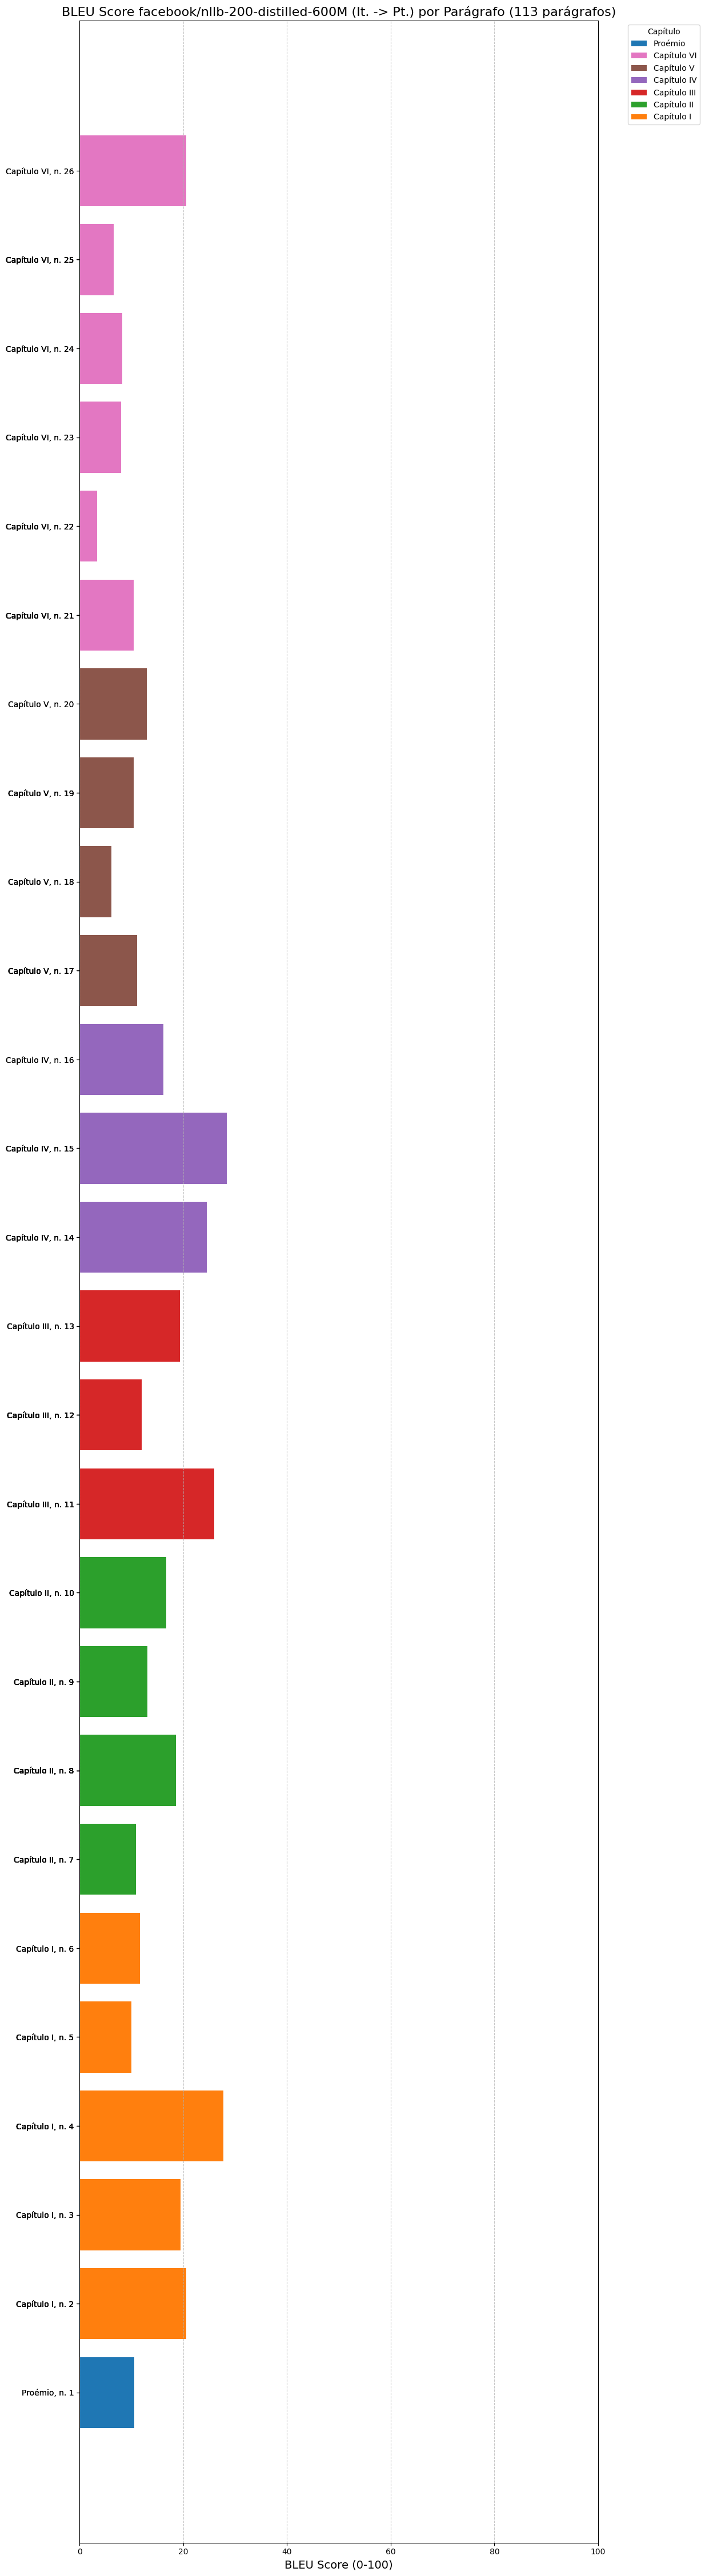

In [ ]:
import re
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline # Import necessary components
import sacrebleu # Ensure sacrebleu is imported

# Initialize NLLB translator for paragraph-by-paragraph translation
model_name = 'facebook/nllb-200-distilled-600M' # Using NLLB for this plot, as an example
src_lang = 'it'
tgt_lang = 'pt'

code_map = {
    'it': 'ita_Latn',
    'pt': 'por_Latn',
    'en': 'eng_Latn'
}
src = code_map.get(src_lang, src_lang)
tgt = code_map.get(tgt_lang, tgt_lang)

tokenizer = AutoTokenizer.from_pretrained(model_name, src_lang=src)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

forced_bos_id = tokenizer.convert_tokens_to_ids(f'__{tgt}__')
if forced_bos_id is None:
     raise ValueError(f"Target language token '___{tgt}__' not found in NLLB tokenizer's vocabulary.")

translator = pipeline('translation', model=model, tokenizer=tokenizer, src_lang=src, tgt_lang=tgt)


# 1. Split TEXTO_ITALIANO into paragraphs and titles
def process_text_for_plotting(text):
    titles_for_plot = []
    paragraphs_for_plot = []

    # Split the entire text by double newlines or lines starting with titles
    # This regex attempts to find title lines and then captures subsequent quoted blocks
    # associated with that title until a new title or end of text.

    # This pattern captures the title line and then all subsequent quoted blocks
    # until another title or the end of the string. re.DOTALL is crucial for '.' to match newlines.
    pattern = re.compile(r'(Proémio, n\. \d+|Capítulo \w+, n\. \d+)\s*(.*?)(?=(Proémio, n\. \d+|Capítulo \w+, n\. \d+)|$)', re.DOTALL)

    for match in pattern.finditer(text):
        current_section_title = match.group(1).strip()
        content_block = match.group(2).strip()

        # Split the content_block into individual quoted paragraphs
        quoted_paragraphs = re.findall(r'"(.*?)"', content_block, re.DOTALL)

        for para_content in quoted_paragraphs:
            if para_content.strip(): # Only add if content is not empty
                titles_for_plot.append(current_section_title)
                paragraphs_for_plot.append(para_content.strip())

    return titles_for_plot, paragraphs_for_plot

all_titles, original_paragraphs = process_text_for_plotting(TEXTO_ITALIANO)

# 2. Translate each paragraph
translated_paragraphs = []
for i, para in enumerate(original_paragraphs):
    if not para.strip():
        translated_paragraphs.append("")
        continue

    try:
        # `truncation=True` will now truncate based on tokenizer.model_max_length (1024)
        # Removed `max_length` from here, as it primarily controls output length for text2text pipelines.
        translation_result = translator(para, truncation=True)
        translated_para = translation_result[0]['translation_text']
    except Exception as e:
        print(f"Error translating paragraph {i+1} (Title: {all_titles[i]}, First 50 chars: {para[:50]}...): {e}")
        translated_para = "Translation Error"
    translated_paragraphs.append(translated_para)

# Concatenate translated paragraphs to form the complete translation for BLEU score
traducao = " ".join(translated_paragraphs)

# 3. Calculate BLEU scores for each paragraph
scores = []
min_len = min(len(original_paragraphs), len(translated_paragraphs))

for i in range(min_len):
    try:
        if original_paragraphs[i] and translated_paragraphs[i]:
            # This calculates BLEU comparing translated Portuguese to original Italian (source).
            # This is not a standard evaluation for translation quality and will yield very low scores.
            # For a proper BLEU, it should be against a human-translated reference in Portuguese.
            score = sacrebleu.sentence_bleu(translated_paragraphs[i], [original_paragraphs[i]]).score
        else:
            score = 0.0
    except Exception as e:
        print(f"Error calculating BLEU for paragraph {i+1} (Title: {all_titles[i]}, First 50 chars original: {original_paragraphs[i][:50]}..., First 50 chars translated: {translated_paragraphs[i][:50]}...): {e}")
        score = 0.0
    scores.append(score)

# 4. Define COLOR_MAP and get_chapter_prefix
COLOR_MAP = {
    'P.': '#1f77b4',  # Blue for Proémio
    'C. I': '#ff7f0e', # Orange for Capítulo I
    'C. II': '#2ca02c', # Green for Capítulo II
    'C. III': '#d62728', # Red for Capítulo III
    'C. IV': '#9467bd', # Purple for Capítulo IV
    'C. V': '#8c564b', # Brown for Capítulo V
    'C. VI': '#e377c2', # Pink for Capítulo VI
}

def get_chapter_prefix(title):
    if title.startswith('Proémio'):
        return 'P.'
    elif title.startswith('Capítulo'):
        match = re.match(r'Capítulo (\w+)', title)
        if match:
            return f'C. {match.group(1)}'
    return 'Other'

# 5. Generate colors and range_label
colors = [COLOR_MAP.get(get_chapter_prefix(title), '#7f7f7f') for title in all_titles]
range_label = f"{len(scores)} parágrafos"

# The plotting code from the original cell, which now has all variables defined:
plt.figure(figsize=(12, max(6, len(all_titles) * 0.4))) # Adjust figure size dynamically
plt.barh(all_titles, scores, color=colors)

# Títulos e Rótulos (ajustados para gráfico horizontal)
plt.title(f'BLEU Score {model_name} (It. -> Pt.) por Parágrafo ({range_label})', fontsize=16)
plt.xlabel('BLEU Score (0-100)', fontsize=14) # Eixo X é o score
plt.yticks(all_titles, rotation=0, fontsize=10) # Rótulos dos parágrafos no Eixo Y
plt.xlim(0, 100) # Define limite máximo para consistência visual no eixo X
plt.grid(axis='x', linestyle='--', alpha=0.7) # Grid no eixo X

# A lógica de adicionar texto com scores foi removida daqui, conforme solicitado.

# Ajusta o layout para dar espaço à legenda
plt.tight_layout(rect=[0, 0, 0.9, 1])

# Criar uma legenda manual para as cores dos capítulos
present_chapters = sorted(list(set(get_chapter_prefix(t) for t in all_titles)))
present_chapters.reverse() # Reverte para que a legenda siga a ordem do gráfico
legend_handles = [plt.Rectangle((0, 0), 1, 1, fc=COLOR_MAP[key]) for key in present_chapters]
legend_labels = [f"Capítulo {key.replace('C. ', '')}" if key != 'P.' else "Proémio" for key in present_chapters]

# Posicionar a legenda fora do gráfico
plt.legend(legend_handles, legend_labels, title="Capítulo", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()